<a href="https://colab.research.google.com/github/mattu117117/For-classroom/blob/main/ex3_B231810.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ex3-0 学籍番号、氏名　←（記入してください）

## ex3-1 課題に取り組む準備
1.   クラスルームから ex3_B123456.ipynb （このファイル）をダウンロードする。
2.   ファイル名を自分の学生番号に変更する。
3.   google drive のLecture3 を置いたォルダと同じ場所にアップする。
5.   colab で ex2_B999999.ipynb を開き課題に取り組む。

In [ ]:
# 下記セルを実行すると、authorization codeの入力を求められます。
# 出力されたリンク先をクリックし、Googleアカウントにログインし、
# authorization codeをコピーし、貼り付けをおこなってください。
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
project = '25SA_Ex'
chapter = 3
os.chdir(f'/content/drive/MyDrive/授業/{project}/Lecture{chapter}/')   # ←自分の環境に合うように適宜修正してください。

## ex3-2 データの準備
Lecture3.ipynb のノック41～ノック44 の内容の繰り返しです。ここを実行すると、data が完成します。これを使ってグラフの作り方を確認しましょう。実行前にコードに一通り目を通し、処理のかたまりごとにコメントを付けていくと良いでしょう。

2021-01-15 09:00:00.144000
2021-02-14 17:59:59.956000
30 days 08:59:59.812000


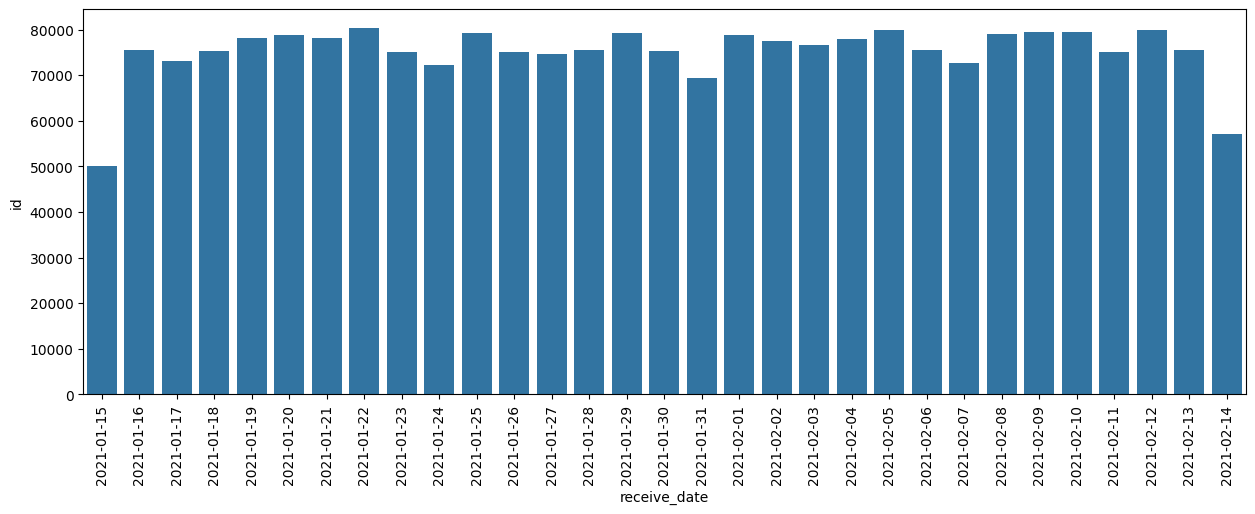

In [ ]:
from glob import glob
files = glob('data/person_count_1sec/out_0001/*.csv')
files.sort()
# display(files[:5])
# display(len(files))

import pandas as pd

data = []
for f in files:
  # tmp = pd.read_csv(f, parse_dates=["receive_time"]) # 読み込みつつ変換できれば高効率だが、何故かうまくいかない。しかたがないので以下の2行で処理します。
  tmp = pd.read_csv(f)
  tmp['receive_time'] = pd.to_datetime(tmp['receive_time'],errors='coerce')
  data.append(tmp)
data = pd.concat(data,ignore_index=True)
#display(data.head())
len(data)

min_receive_time = data['receive_time'].min()
max_receive_time = data['receive_time'].max()
print(min_receive_time)
print(max_receive_time)

print(data['receive_time'].max()-data['receive_time'].min())

data['receive_date'] = data['receive_time'].dt.date
# display(data.head())

daily_count = data[['receive_date','id']].groupby('receive_date', as_index=False).count()
#daily_count.head()

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.xticks(rotation=90)
sns.barplot(x=daily_count['receive_date'], y=daily_count["id"])

data['dayofweek'] = data['receive_time'].dt.dayofweek
data['day_name'] = data['receive_time'].dt.day_name()
#data.head()

#data[['receive_date','dayofweek','day_name']].drop_duplicates(subset='receive_date').head(12)



## ex3-3 データの絞り込み
２月１日から７日までの７日間にデータを絞り込んで、新しいデータフレーム data_extract2 を作りなさい。



## ex3-4 秒単位のデータの作成

ノック46と47を参考に、重複がなく漏れもない秒単位データを次の手順で作成しなさい。

1. floor を使った切り捨てで、data_extract2 に秒単位データのカラムを追加する。
2. 秒単位のカラムで重複しているデータを削除する。
3. 対象とする範囲で、１秒間隔データ base_data2 を作成する。
4. base_data2 と data_extract2 を merge して、data_base_extract2 を作る
5. data_base_extract2 のうち NaN のセルを前のセルの値で埋める


## ex3-5 通った人数の可視化
data_base_extract2 を使って、次の手順でデータを可視化せよ。

1. data_analytics2 という名称で必要なカラムに絞ってデータフレームを作成する。
2. data_analytics2 から１秒前のデータを作成する。
3. index をキーに横方向に結合
4. 引き算をして、その結果を 'in1_calc'などのカラムを作成して記録
5. 日付と時間を文字列で示すカラムを作り、時間谷で集計する。
6. 縦持ちデータに変換する。
7. 横軸に時間、縦軸に通った人数を示す折れ線グラフを作成する。




## ex3-6 移動平均を計算して可視化する
移動平均を計算する際の平均をとるデータの幅を widow 幅（あるいは単にwindow）と言ったりします。次の手順で widow 幅 を様々に変えた移動平均のグラフを作成し、widow 幅の値とグラフの見え方の関係を観察しなさい。

移動平均グラフを作る手順
1.   data_analytics2 より不要なカラムを削除した viz_data2 を作成する。
2.   viz_data2 に rolling(win_width) を適用し移動平均データを作成する。ただし、win_width=3 などあらかじめ win_width の値を設定しておく。
3. melt を使って縦持ちデータに変換する。
4. date_hour のカラムを追加する。
5. グラフを描画する。






<Axes: xlabel='date_hour', ylabel='value'>

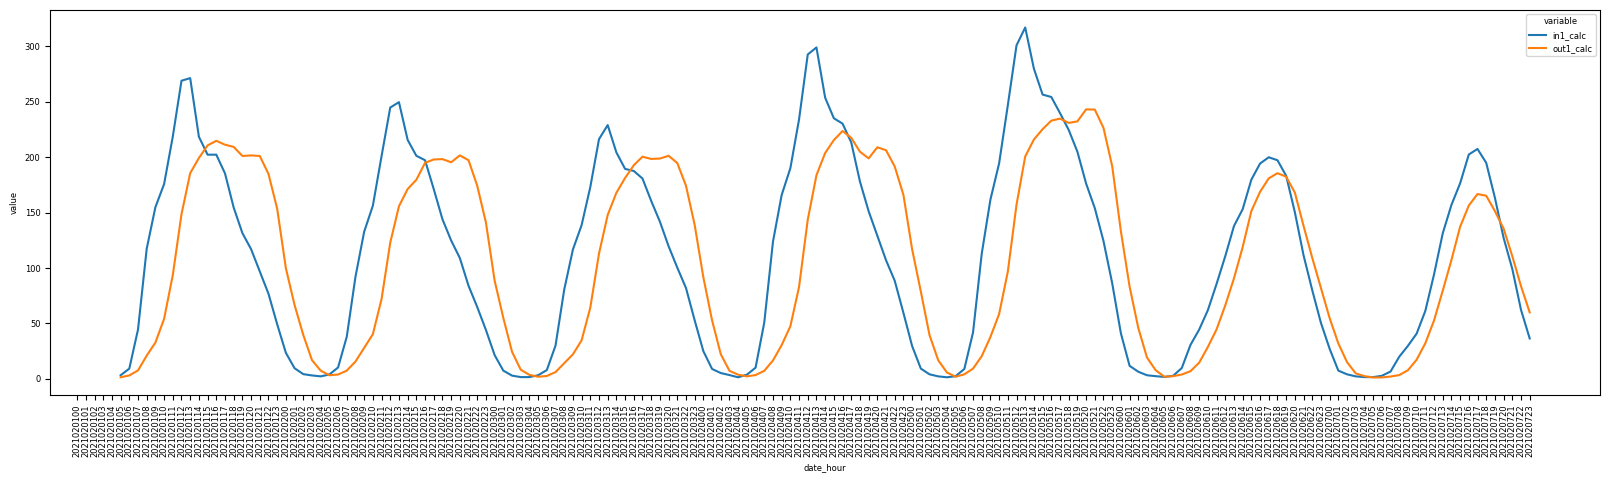

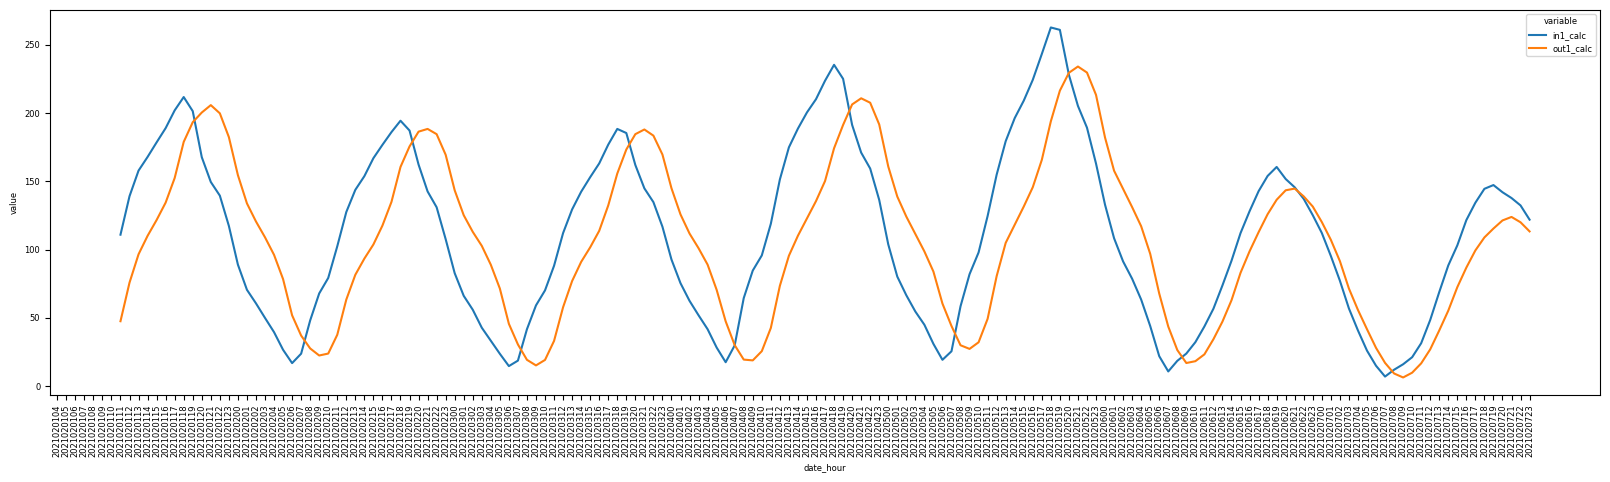

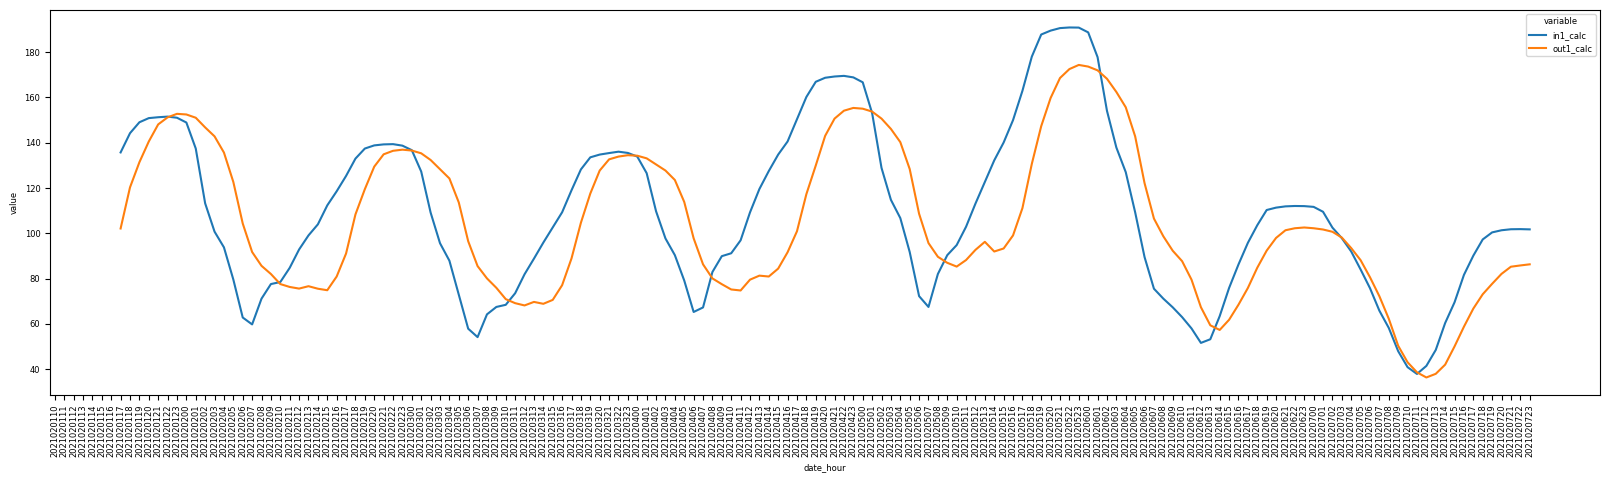

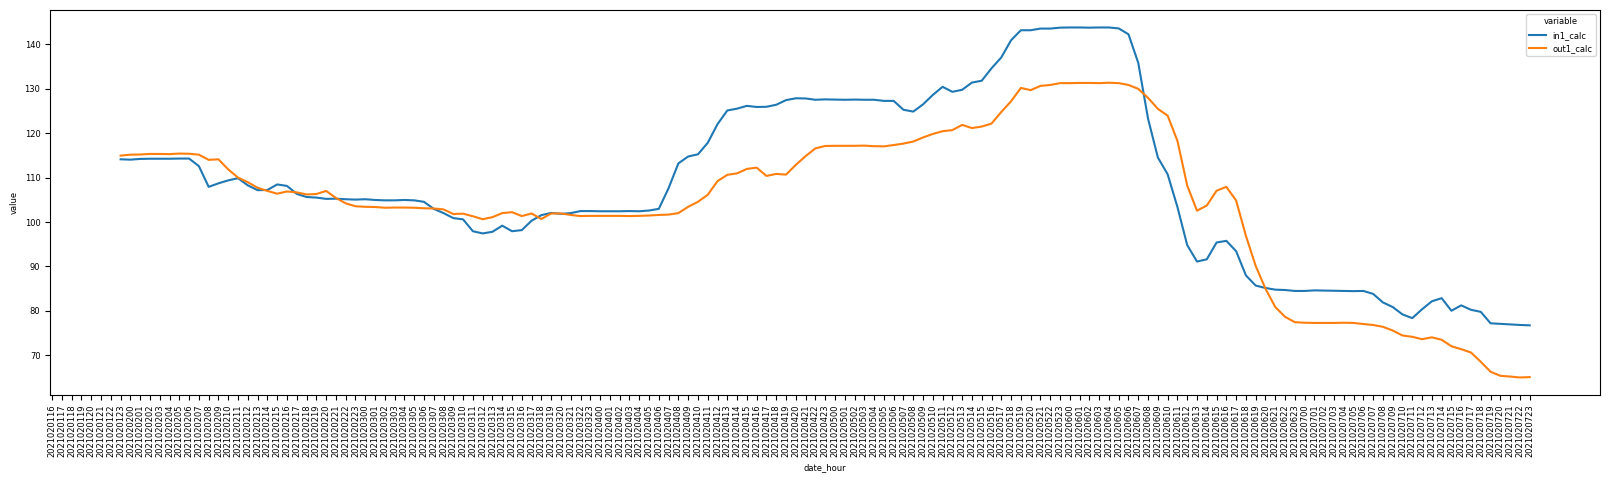

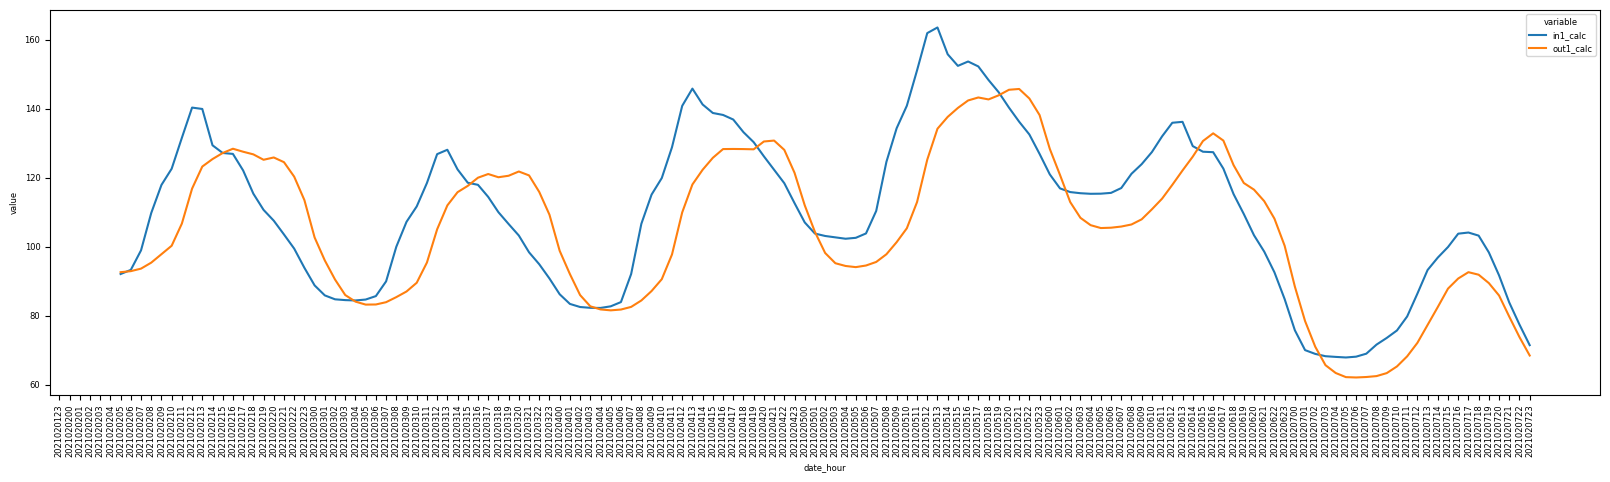

Q1　移動平均グラフで、出勤、昼休憩、退勤の違いが分かるようにするためには、win_width の値はいくつぐらいが望ましいか？

Ans. win=

Q2　移動平均グラフで、曜日ごとの違いが分かるようにするためには、win_width の値はいくつからいくつが望ましいか？

Ans. win=

Q3　発展課題（余力のある人はトライ）移動平均グラフで、win=12,18,24,30,36,42,48, 52 としていくとグラフの様子はどのように変化しますか？また、その理由は何故でしょうか？

Ans.